In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

In [41]:
aln = ALNModel()

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 2.

In [43]:
aln = ALNModel()

aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

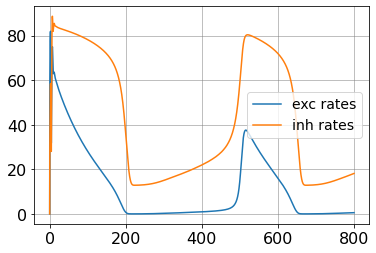

In [44]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

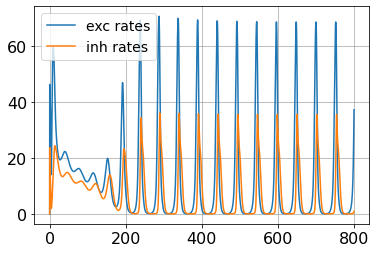

In [45]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

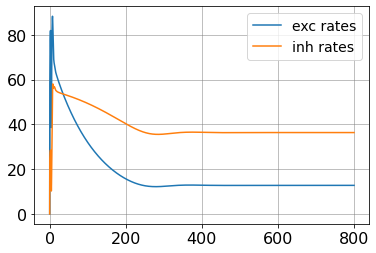

[12.7573 36.3483]


In [48]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

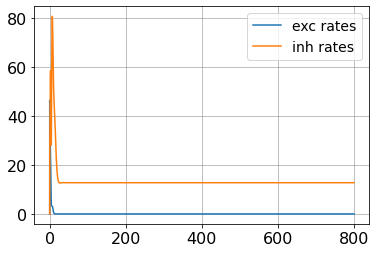

[2.7642e-06 1.2727e+01]


In [49]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

### E

In [79]:
dur = 1000
dur_pre = 400
dur_post = 400
aln.params.duration = dur

set_params_fast()

control0 = aln.getZeroControl()

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = up_rates[0]
target[:,1,:] = up_rates[1]

tol = 1e-12
start_step = 10.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [82]:
# E.a.1) fast osc => high, max current 1nA, precision only
case = "Ea1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

max_it = 10

setinit(fast_osc_init)

control0 = aln.getZeroControl()
control0[:,0,:] = 1.5
control0[:,1,:] = 1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
control1 = bestControlEa1[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlEa1, bestStateEa1, costEa1, runtimeEa1, gradEa1 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultEa1 = {"Opt_control": bestControlEa1,
              "Opt_state": bestStateEa1,
              "costArray": costEa1,
              "runtimeArray": runtimeEa1,    
}

dump_dicts = [opt_params, aln.params, resultEa1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  38778.2244911686
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  14795.989036038425
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  2 , total integrated cost =  12548.927487305175
RUN  3 , total integrated cost =  11613.539293236234
RUN  4 , total integrated cost =  10859.603666338422
RUN  5 , total integrated cost =  10275.004839295592
RUN  6 , total integrated cost =  9765.453852425408
RUN  7 , total integrated cost =  9308.940738438492
RUN  8 , total integrated cost =  8888.09575598591
RUN  9 , total integrated cost =  8493.790114329602


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  8124.478393689338
Improved over  10  iterations by  79.04886440703437  percent.
Problem in initial value trasfer:  Vmean_exc -62.14599077384011 -62.10046562072483
Problem in initial value trasfer:  Vmean_exc -56.798148478168436 -56.79814386083639


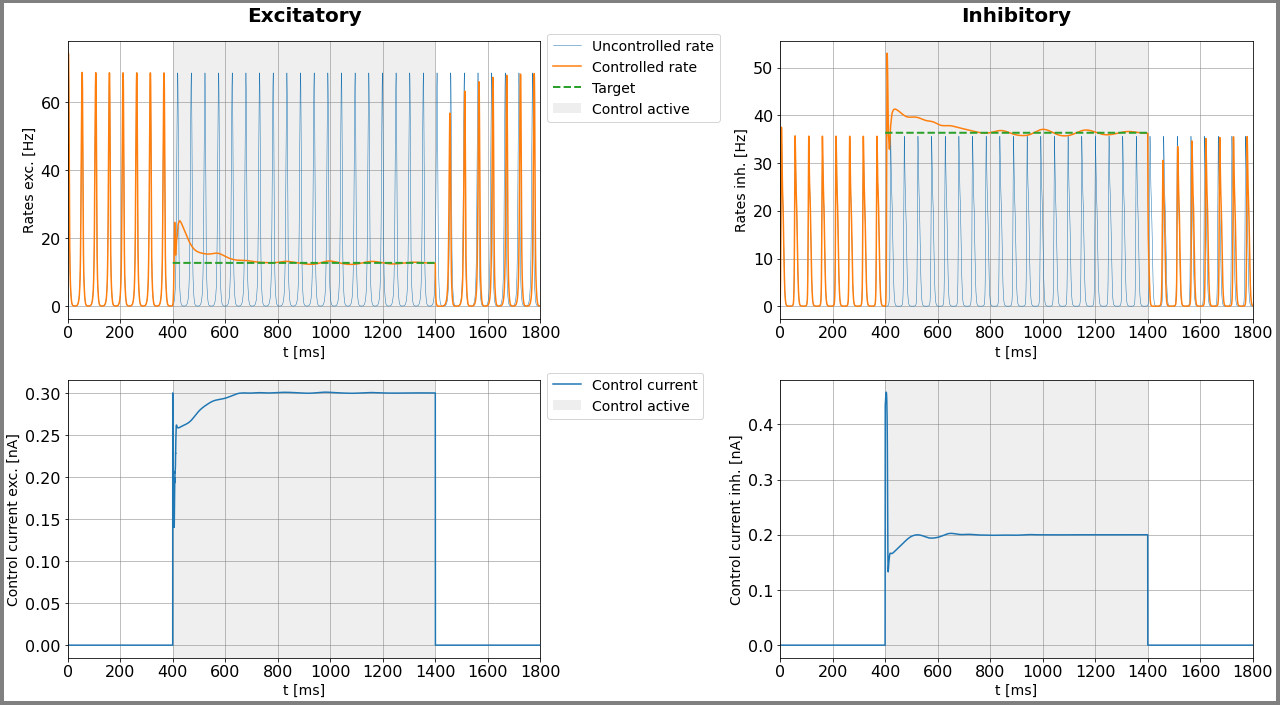

In [91]:
plotFunc.plot_control(aln, bestControlEa1, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

In [98]:
# E.a.2) fast osc => high, max current 1nA, precision + energy + sparsity
case = "Ea2"
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

max_it = 10

setinit(fast_osc_init)
control0 = aln.getZeroControl()
control0[:,0,:] = 1.5
control0[:,1,:] = 1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlEa2[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlEa2, bestStateEa2, costEa2, runtimeEa2, gradEa2 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultEa2 = {"Opt_control": bestControlEa2,
              "Opt_state": bestStateEa2,
              "costArray": costEa2,
              "runtimeArray": runtimeEa2,    
}

dump_dicts = [opt_params, aln.params, resultEa2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  40482.44788542049
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  16453.48978997862
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  2 , total integrated cost =  14204.70053584177
RUN  3 , total integrated cost =  13261.880542017268
RUN  4 , total integrated cost =  12509.17926005103
RUN  5 , total integrated cost =  11921.432359045033
RUN  6 , total integrated cost =  11393.8394121266
RUN  7 , total integrated cost =  10916.906165178023
RUN  8 , total integrated cost =  10478.691348958271
RUN  9 , total integrated cost =  10093.798795239289


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  9732.185511302625
Improved over  10  iterations by  75.9594935097598  percent.
Problem in initial value trasfer:  Vmean_exc -62.14599077384011 -62.10046562072483
Problem in initial value trasfer:  Vmean_exc -56.79847232250536 -56.79847557124484


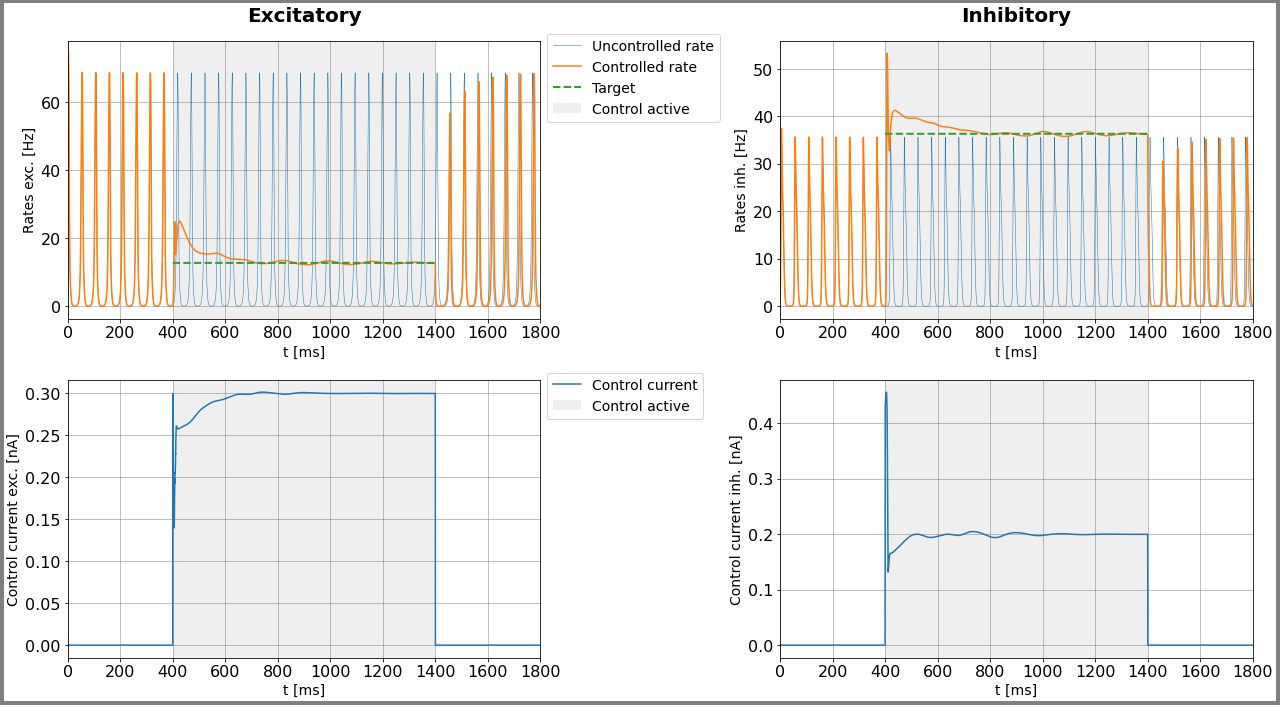

In [99]:
plotFunc.plot_control(aln, bestControlEa2, dur, dur_pre, dur_post, fast_osc_init, target,
                      path, filename_ = case )

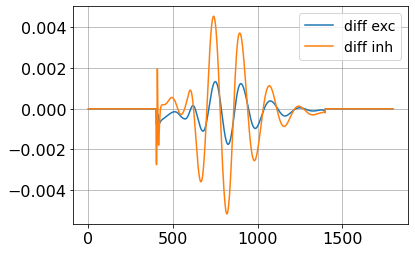

In [100]:
diff = 0.2*(bestControlEa2 - bestControlEa1)

t = np.arange(0, (dur+dur_pre+dur_post+0.1), 0.1)
plt.plot(t, diff[0,0,:], label = "diff exc")
plt.plot(t, diff[0,1,:], label = "diff inh")
plt.legend()
plt.show()

In [101]:
# E.b.1) slow osc => high, max current 1nA, precision only
case = "Eb1"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

max_it = 10

set_params_slow()
setinit(slow_osc_init)

control0 = aln.getZeroControl()
control0[:,1,:] = -1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
control1 = bestControlEa1[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlEb1, bestStateEb1, costEb1, runtimeEb1, gradEb1 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultEb1 = {"Opt_control": bestControlEb1,
              "Opt_state": bestStateEb1,
              "costArray": costEb1,
              "runtimeArray": runtimeEb1,    
}

dump_dicts = [opt_params, aln.params, resultEb1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  44495.57235921333
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  30826.157452027477
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
too large start step, decrease to  0.0006103515625
RUN  2 , total integrated cost =  27003.984281408484
RUN  3 , total integrated cost =  24236.303460036474
RUN  4 , total integrated cost =  22883.896800642422
RUN  5 , total integrated cost =  21659.809529623217
RUN  6 , total integrated cost =  20649.659045824195
RUN  7 , total integrated cost =  19771.01320087706
RUN  8 , total integrated cost =  18971.86631679233
RUN  9 , total integrated cost =  18232.402111602212


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  17517.75341230781
Improved over  10  iterations by  60.630344810744845  percent.
Problem in initial value trasfer:  Vmean_exc -62.89125640925941 -62.887760885430545
Problem in initial value trasfer:  Vmean_exc -56.800158177441375 -56.800180648902725


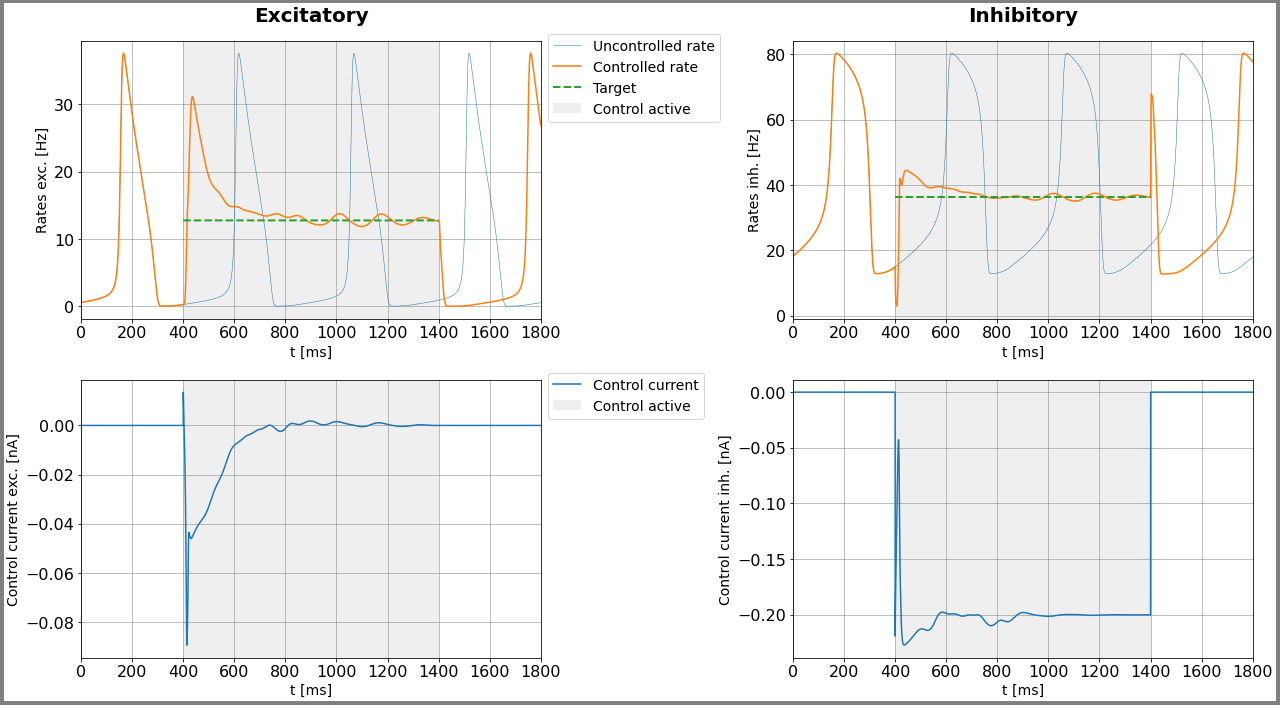

In [103]:
plotFunc.plot_control(aln, bestControlEb1, dur, dur_pre, dur_post, slow_osc_init, target,
                      path, filename_ = case )

In [104]:
# E.b.2) slow osc => high, max current 1nA, precision + energy + sparsity
case = "Eb2"
cost.setParams(1.0, 1.0, 1.0)
max_cntrl = 1. * 5.
aln.params.duration = dur

max_it = 10

setinit(slow_osc_init)
control0 = aln.getZeroControl()
control0[:,0,:] = 1.5
control0[:,1,:] = 1.

n_pre = int(dur_pre / aln.params.dt)
n_post = int(dur_post / aln.params.dt)
#control1 = bestControlEa2[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlEb2, bestStateEb2, costEb2, runtimeEb2, gradEb2 = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv)

resultEb2 = {"Opt_control": bestControlEb2,
              "Opt_state": bestStateEb2,
              "costArray": costEb2,
              "runtimeArray": runtimeEb2,    
}

dump_dicts = [opt_params, aln.params, resultEb2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  2961095.63261009
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  94839.74536106533
too large start step, decrease to  0.078125
RUN  2 , total integrated cost =  81632.60419830336
too large start step, decrease to  0.078125
RUN  3 , total integrated cost =  80854.09763034203
RUN  4 , total integrated cost =  80534.7929964522
too large start step, decrease to  0.0006103515625
RUN  5 , total integrated cost =  80233.77886271171
too large start step, decrease to  0.0006103515625
RUN  6 , total integrated cost =  80110.79228055668
RUN  7 , total integrated cost =  80059.63644077153
too large start step, decrease to  0.0006103515625
RUN  8 , total integrated cost =  79982.99725573111
too small start step, increase to  0.078125
RUN  9 , total integrated cost =  79931.92988478977


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


too large start step, decrease to  0.0006103515625
RUN  10 , total integrated cost =  79873.90222793726
Improved over  10  iterations by  97.30255580575317  percent.
Problem in initial value trasfer:  Vmean_exc -62.89125640925941 -62.887760885430545
Problem in initial value trasfer:  Vmean_exc -61.67083930224071 -61.68069145965925


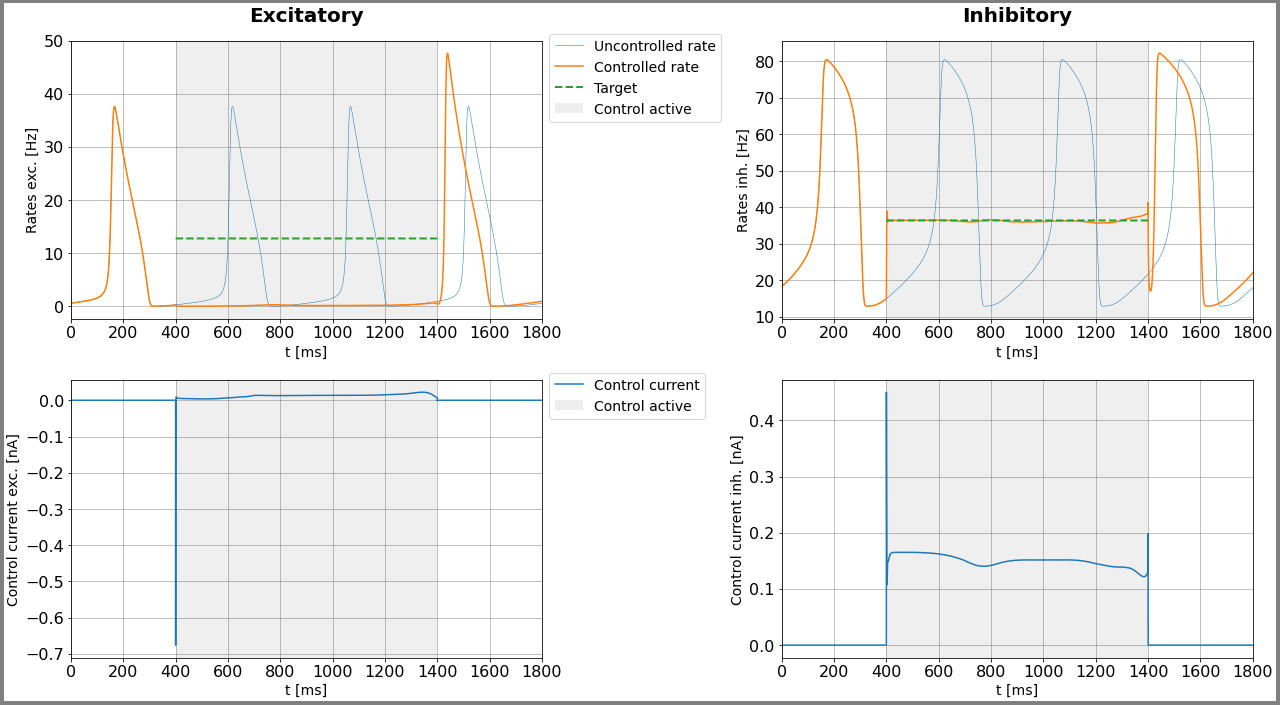

In [105]:
plotFunc.plot_control(aln, bestControlEb2, dur, dur_pre, dur_post, slow_osc_init, target,
                      path, filename_ = case )